This notebook verifies **energy conservation** under time evolution via the
Time-Evolving Block Decimation (TEBD) algorithm.
A product state is initialized with `init_mps`, evolved under a nearest-neighbor
Hamiltonian, and the total energy $\langle H \rangle$ is tracked at each time step.

---

##### 💠 **Build the Two-Site Hamiltonian. A Spin-$\frac{1}{2}$ ferromagnetic chain can be modeled as,$$\boxed{H_{n}=-B\sum_{l=1}^{n}\sigma_{z}^{[l]}-J\sum_{l=1}^{n-1}\vec{\sigma}^{[l]}\cdot\vec{\sigma}^{[l+1]}}$$**
Where the
*   **$H_n$**: Represents the Hamiltonian for a chain of $n$ spins.
*   **$B$**: Denotes the strength of the external magnetic field acting in the $z$ direction.
*   **$J$**: Represents the coupling constant for the interaction between adjacent spins.
*   **$\sigma_z^l$**: Is the Pauli-$Z$ matrix or operator for the $l$-th spin.
*   **$\vec{\sigma}_l \cdot \vec{\sigma}_{l+1}$**: Describes the dot product interaction between the vector spin operators of neighboring spins $l$ and $l+1$.

In [1]:
import sys
import os
import numpy as np
from scipy.linalg import expm
from typing import List, Tuple
sys.path.append(os.path.abspath("..")) 
from src.mps        import init_mps
from src.hamiltonian import build_xxz_two_site, build_trotter_gates,build_full_hamiltonian
from src.tebd        import tebd_sweep
from src.observables import compute_energy, entanglement_entropy_bond, entanglement_entropy_profile
from src.utils       import is_converged
import matplotlib.pyplot as plt


##### ✨ **Parameters**

| Symbol | Variable | Description |
|--------|----------|-------------|
| $L$ | `L` | Number of sites |
| $d$ | `d` | Local Hilbert-space dimension |
| $\chi$ | `chi` | Maximum bond dimension |
| $\delta t$ | `dt` | Trotter time step |
| $T$ | `T` | Total evolution time |
| $J, h$ | `J`, `h` | Coupling / field strength |

In [20]:
# --- Physical parameters ---
n_sites = 20  #L
d       = 2
chi_max = 17
dt      = 0.005
n_steps = 2000
Jx, Jy, Jz, hz = -1.0, -1.0, -1.0, 1.0

# --- Initial state |↓↓↑↑↑↑↑↑↑↑⟩ ---
# config           = [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
config             = [("down", 2),("up", n_sites-2)]
A_list, lam_list = init_mps(config)

# --- Hamiltonian and gates ---
h_left, h_bulk, h_right = build_xxz_two_site(Jx, Jy, Jz, hz)
even_gates, odd_gates     = build_trotter_gates(h_left, h_bulk, h_right, dt)

print(f"System   : {n_sites} sites, d={d}")
print(f"State    : {config}")
print(f"chi_max  : {chi_max}")
print(f"dt       : {dt},  n_steps : {n_steps},  t_final : {n_steps * dt:.2f}")

System   : 20 sites, d=2
State    : [('down', 2), ('up', 18)]
chi_max  : 17
dt       : 0.005,  n_steps : 2000,  t_final : 10.00


#### 🌺 **Results**
The plot below shows $\langle H \rangle$ vs time $t$.
Deviations from the initial value indicate accumulated error from:

- **Trotter error** — scales as $O(\delta t^2)$ per step; reduce by decreasing `dt`
- **Truncation error** — from discarding singular values below `chi`; reduce by increasing `chi`

In [21]:
# Reshape bond Hamiltonians to (d,d,d,d) for compute_energy
h_left_4  = h_left.reshape(d, d, d, d)
h_bulk_4  = h_bulk.reshape(d, d, d, d)
h_right_4 = h_right.reshape(d, d, d, d)

# --- Initial observables ---
central_bond = n_sites // 2

E0 = compute_energy(A_list, lam_list, h_left_4, h_bulk_4, h_right_4)
S0 = entanglement_entropy_bond(lam_list[central_bond])

times    = [0.0]
energies = [E0]
entropy  = [S0]

print(f"{'step':>6}  {'time':>8}  {'E(t)':>16}  {'|ΔE|':>12}  {'S(L/2)':>12}")
print("-" * 62)
print(f"{'0':>6}  {0.0:>8.4f}  {E0:>16.8f}  {'---':>12}  {S0:>12.6f}")

# --- Time evolution ---
for step in range(n_steps):

    # Second-order Suzuki-Trotter: even(dt/2) → odd(dt) → even(dt/2)
    tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0)
    tebd_sweep(A_list, lam_list, odd_gates,  chi_max, parity=1)
    tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0)

    # Observables
    E = compute_energy(A_list, lam_list, h_left_4, h_bulk_4, h_right_4)
    S = entanglement_entropy_bond(lam_list[central_bond])
    t = (step + 1) * dt

    times.append(t)
    energies.append(E)
    entropy.append(S)

    if (step + 1) % 20 == 0:
        dE = abs(E - E0)
        print(f"{step+1:>6}  {t:>8.4f}  {E:>16.8f}  {dE:>12.2e}  {S:>12.6f}")

# --- Convert to arrays ---
times    = np.array(times)
energies = np.array(energies)
entropy  = np.array(entropy)

# --- Final diagnostics ---
dE_rel = np.max(np.abs((energies - E0) / E0))
print()
print("=" * 50)
print(f"Initial energy          : {E0:.8f}")
print(f"Final energy            : {energies[-1]:.8f}")
print(f"Max |ΔE/E0| over run    : {dE_rel:.2e}")

  step      time              E(t)          |ΔE|        S(L/2)
--------------------------------------------------------------
     0    0.0000       -1.00000000           ---     -0.000000
    20    0.1000       -0.99999124      8.76e-06     -0.000000
    40    0.2000       -0.99996954      3.05e-05     -0.000000
    60    0.3000       -0.99994610      5.39e-05      0.000000
    80    0.4000       -0.99993264      6.74e-05      0.000000
   100    0.5000       -0.99993504      6.50e-05      0.000000
   120    0.6000       -0.99995044      4.96e-05      0.000000
   140    0.7000       -0.99996946      3.05e-05      0.000000
   160    0.8000       -0.99998206      1.79e-05      0.000000
   180    0.9000       -0.99998315      1.69e-05      0.000002
   200    1.0000       -0.99997465      2.53e-05      0.000012
   220    1.1000       -0.99996303      3.70e-05      0.000052
   240    1.2000       -0.99995474      4.53e-05      0.000180
   260    1.3000       -0.99995280      4.72e-05      0

##### 📊 **Error Analysis**

Define the relative energy drift as:

$$\epsilon(t) = \frac{|\langle H \rangle(t) - \langle H \rangle(0)|}{|\langle H \rangle(0)|}$$

Good conservation is typically $\epsilon < 10^{-4}$ for moderate $\chi$ and small $\delta t$.


  Figures → energy_conservation.png.png


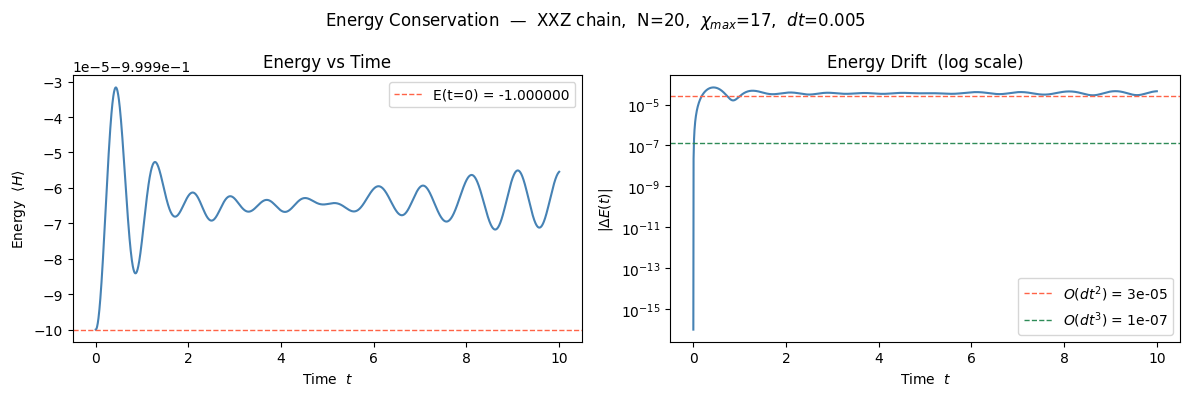

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left panel: E(t) over time ---
axes[0].plot(times, energies, color="steelblue", linewidth=1.5)
axes[0].axhline(energies[0], color="tomato", linestyle="--", linewidth=1, label=f"E(t=0) = {energies[0]:.6f}")
# axes[0].set_ylim(-1.5, 0)
axes[0].set_xlabel("Time  $t$")
axes[0].set_ylabel("Energy  $\\langle H \\rangle$")
axes[0].set_title("Energy vs Time")
axes[0].legend()

# --- Right panel: |ΔE(t)| drift on log scale ---
drift = np.abs(energies - energies[0])
drift[drift == 0] = 1e-16    # avoid log(0) for the first point

axes[1].semilogy(times, drift, color="steelblue", linewidth=1.5)
axes[1].axhline(dt**2, color="tomato",   linestyle="--", linewidth=1, label=f"$O(dt^2)$ = {dt**2:.0e}")
axes[1].axhline(dt**3, color="seagreen", linestyle="--", linewidth=1, label=f"$O(dt^3)$ = {dt**3:.0e}")
axes[1].set_xlabel("Time  $t$")
axes[1].set_ylabel("$|\\Delta E(t)|$")
axes[1].set_title("Energy Drift  (log scale)")
axes[1].legend()

fig.suptitle(
    f"Energy Conservation  —  XXZ chain,  N={n_sites},  "
    f"$\\chi_{{max}}$={chi_max},  $dt$={dt}",
    fontsize=12
)
fig.tight_layout()
plt.savefig("../figures/energy_conservation.png", dpi=150)
print("\n  Figures → energy_conservation.png.png")
plt.show()

#### 🍁 **Exact Diagonalization (ED) Benchmark for Small Systems**
For small system sizes $L \leq 14$, we can evolve the full $2^L$-dimensional state vector exactly using
$$\exp(-iHt)$$
and compare the Schmidt values at every bond with those obtained from TEBD.

#### **Why Schmidt Values?**
The Schmidt values are basis-independent — they do not depend on any gauge choice in the MPS. Hence they are the cleanest quantity to compare. If the Schmidt values match ED, the physical state is correct.

#### **Index Rule (Critical)**
The correspondence is
$$\texttt{lam\_list}[b] \longleftrightarrow \text{ED cut between } d^b \text{ (left)} \text{ and } d^{\,n-b} \text{ (right)}.$$
That is, reshape $\psi$ as
$$(d^b,\; d^{\,n-b})$$
and perform an SVD. The singular values are the Schmidt values across bond $b$.

Bond mapping:
$b=1 \rightarrow 0|1$,  
$b=2 \rightarrow 1|2$,  
$\dots$,  
$b=n-1 \rightarrow (n-2)|(n-1)$.

In [23]:
N_SITES         = 10
D               = 2
CHI_MAX         = 4
DT              = 0.005
N_STEPS         = 50
JX, JY, JZ, HZ = -1.0, -1.0, -1.0, 1.0
CONFIG          = [("down", 2), ("up", N_SITES - 2)]

# Steps at which the per-bond Schmidt table is printed (0-based)
_PRINT_STEPS: frozenset = frozenset({0, 4, 9, 24, 49})

In [24]:

def _ed_schmidt_values(
    psi: np.ndarray,
    bond: int,
    n_sites: int,
    d: int,
) -> np.ndarray:
    """Compute normalised Schmidt values for a bipartition of the ED state.

    Bipartitions the chain at ``bond``, reshapes the state vector into
    a matrix of shape ``(d**bond, d**(n_sites-bond))``, and returns
    the singular values normalised so that Σ λ² = 1.

    Parameters
    ----------
    psi : ndarray, shape (d**n_sites,)
        Full state vector.
    bond : int
        Bond index in ``[1, n_sites-1]``. The left block contains
        sites ``0, …, bond-1``.
    n_sites : int
        Total number of sites.
    d : int
        Local Hilbert-space dimension.

    Returns
    -------
    schmidt : ndarray, shape (rank,)
        Normalised Schmidt values in descending order.
    """
    dim_left  = d ** bond
    dim_right = d ** (n_sites - bond)
    psi_mat   = psi.reshape(dim_left, dim_right)

    _, singular_values, _ = np.linalg.svd(psi_mat, full_matrices=False)

    # Keep only non-negligible values and normalise
    singular_values = singular_values[singular_values > 1e-15]
    norm            = np.linalg.norm(singular_values)
    return singular_values / norm if norm > 0 else singular_values

In [25]:
def _config_to_statevector(
    config: list,
    n_sites: int,
    d: int,
) -> np.ndarray:
    """Build a normalised product-state vector from a tuple config.

    Converts ``[("down", 2), ("up", 4)]`` to a flat spin list
    ``[0, 0, 1, 1, 1, 1]`` and constructs the corresponding
    computational-basis state in the full Hilbert space.

    Parameters
    ----------
    config : list of (str, int) tuples
        Same format as accepted by :func:`init_mps`.
    n_sites : int
        Total number of sites.
    d : int
        Local Hilbert-space dimension.

    Returns
    -------
    psi : ndarray, shape (d**n_sites,)
        Normalised product-state vector (single nonzero entry = 1).
    """
    # Flatten config → [0, 0, 1, 1, …]  (down=0, up=1)
    flat: List[int] = []
    for label, count in config:
        flat.extend([1 if label == "up" else 0] * count)

    # Standard binary basis index
    basis_index      = sum(s * (d ** (n_sites - 1 - i)) for i, s in enumerate(flat))
    psi              = np.zeros(d ** n_sites, dtype=complex)
    psi[basis_index] = 1.0
    return psi

In [26]:
def _max_schmidt_error(
    sv_ed: np.ndarray,
    sv_tebd: np.ndarray,
) -> float:
    """Max absolute difference between two Schmidt vectors of possibly
    different lengths (shorter one is zero-padded).

    Parameters
    ----------
    sv_ed : ndarray
        Schmidt values from exact diagonalisation.
    sv_tebd : ndarray
        Schmidt values from TEBD (``lam_list[bond]``).

    Returns
    -------
    float
        Max |sv_ed - sv_tebd| after zero-padding.
    """
    pad = max(len(sv_ed), len(sv_tebd))
    a   = np.pad(sv_ed,   (0, pad - len(sv_ed)))
    b   = np.pad(sv_tebd, (0, pad - len(sv_tebd)))
    return float(np.max(np.abs(a - b)))

In [27]:
def run_comparison(
    n_sites:  int   = N_SITES,
    d:        int   = D,
    chi_max:  int   = CHI_MAX,
    dt:       float = DT,
    n_steps:  int   = N_STEPS,
    Jx:       float = JX,
    Jy:       float = JY,
    Jz:       float = JZ,
    hz:       float = HZ,
    config:   list  = CONFIG,
) -> Tuple[List[float], List[float], np.ndarray, List[np.ndarray]]:
    """Compare TEBD Schmidt values against exact diagonalisation at every bond.

    Parameters
    ----------
    n_sites : int
        Number of sites. Keep small (≤ 12) for ED to be feasible.
    d : int
        Local Hilbert-space dimension (default 2 for spin-1/2).
    chi_max : int
        Maximum TEBD bond dimension.
    dt : float
        Time step size.
    n_steps : int
        Number of Trotter steps.
    Jx, Jy, Jz : float
        Exchange couplings (Pauli convention).
    hz : float
        Longitudinal field (Pauli convention).
    config : list
        Initial state in ``init_mps`` tuple format.

    Returns
    -------
    max_errors : list of float, length n_steps
        Max |TEBD Schmidt − ED Schmidt| over all bonds at each step.
    times : list of float, length n_steps
        Simulation time after each step.
    psi_ed : ndarray, shape (d**n_sites,)
        Final ED state vector (for post-hoc analysis and plotting).
    lam_list : list of ndarray, length n_sites+1
        Final TEBD Schmidt vectors (for post-hoc analysis and plotting).
    """
    # ── Build operators ───────────────────────────────────────────────────── #
    h_left, h_bulk, h_right = build_xxz_two_site(Jx, Jy, Jz, hz)
    even_gates, odd_gates   = build_trotter_gates(h_left, h_bulk, h_right, dt)

    H_full  = build_full_hamiltonian(Jx, Jy, Jz, hz, n_sites)
    U_exact = expm(-1j * H_full * dt)

    # ── Initial states ────────────────────────────────────────────────────── #
    A_list, lam_list = init_mps(config)
    psi_ed           = _config_to_statevector(config, n_sites, d)

    # ── Header ───────────────────────────────────────────────────────────── #
    print(f"\n{'='*70}")
    print(f"  TEBD vs Exact Diagonalisation — Schmidt value comparison")
    print(f"{'='*70}")
    print(f"  Sites    : {n_sites}       d       : {d}")
    print(f"  chi_max  : {chi_max}       dt      : {dt}")
    print(f"  n_steps  : {n_steps}       t_final : {n_steps * dt:.3f}")
    print(f"  State    : {config}")
    print(f"{'='*70}\n")

    col_w = 36
    print(f"  {'step':>5}  {'bond':>5}  "
          f"{'ED Schmidt (top 4)':>{col_w}}  "
          f"{'TEBD Schmidt (top 4)':>{col_w}}  "
          f"{'max err':>10}")
    print(f"  {'-' * (5+5+col_w+col_w+10+8)}")

    max_errors: List[float] = []
    times:      List[float] = []

    for step in range(n_steps):

        # ── Advance both methods ──────────────────────────────────────────── #
        psi_ed = U_exact @ psi_ed

        tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0)
        tebd_sweep(A_list, lam_list, odd_gates,  chi_max, parity=1)
        tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0)

        # ── Compare Schmidt values at every bond ──────────────────────────── #
        step_max_err = 0.0
        print_now    = step in _PRINT_STEPS

        for bond in range(1, n_sites):
            sv_ed   = _ed_schmidt_values(psi_ed, bond, n_sites, d)
            sv_tebd = lam_list[bond]
            err     = _max_schmidt_error(sv_ed, sv_tebd)
            step_max_err = max(step_max_err, err)

            if print_now:
                ed_str   = np.array2string(
                    sv_ed[:4],   precision=5, suppress_small=True
                )
                tebd_str = np.array2string(
                    sv_tebd[:4], precision=5, suppress_small=True
                )
                print(f"  {step+1:>5}  {bond:>5}  "
                      f"{ed_str:>{col_w}}  "
                      f"{tebd_str:>{col_w}}  "
                      f"{err:>10.2e}")

        if print_now:
            print(f"  {'':>5}  {'':>5}  "
                  f"{'── max error this step ──':>{col_w}}  "
                  f"{'':>{col_w}}  "
                  f"{step_max_err:>10.2e}\n")

        max_errors.append(step_max_err)
        times.append((step + 1) * dt)

    print(f"\n{'='*70}")
    print(f"  Final max Schmidt error  : {max_errors[-1]:.2e}")
    print(f"  Peak max Schmidt error   : {max(max_errors):.2e}  "
          f"(step {np.argmax(max_errors)+1})")
    print(f"{'='*70}\n")

    return max_errors, times, psi_ed, lam_list

In [28]:
def print_summary(
    max_errors: List[float],
    dt: float = DT,
    chi_max: int = CHI_MAX,
) -> None:
    """Print a formatted summary of overall Trotter error vs expected scaling."""

    overall_max = float(np.max(max_errors))
    trotter_err = dt ** 3   # per-step error is O(dt³) for 2nd-order Trotter
    passed      = overall_max < 1e-4

    print("=" * 55)
    print(f"  Overall max error (all bonds, all steps) : {overall_max:.2e}")
    print(f"  Per-step Trotter error  O(dt³)           : {trotter_err:.2e}")
    print(f"  chi_max used                             : {chi_max}")
    print(f"  (no truncation → error is pure Trotter)  ")
    print(f"  Result : {'PASS ✓' if passed else 'FAIL ✗'}")
    print("=" * 55)

In [29]:
max_errors, times, psi_ed, lam_list = run_comparison()


  TEBD vs Exact Diagonalisation — Schmidt value comparison
  Sites    : 10       d       : 2
  chi_max  : 4       dt      : 0.005
  n_steps  : 50       t_final : 0.250
  State    : [('down', 2), ('up', 8)]

   step   bond                    ED Schmidt (top 4)                  TEBD Schmidt (top 4)     max err
  ----------------------------------------------------------------------------------------------------
      1      1                     [1.      0.00005]                     [1.      0.00005]    3.34e-10
      1      2     [0.99995 0.01    0.      0.     ]                     [0.99995 0.01   ]    2.50e-07
      1      3     [1.      0.00005 0.      0.     ]                     [1.      0.00005]    6.25e-10
      1      4                            [1. 0. 0.]                                  [1.]    1.67e-07
      1      5                               [1. 0.]                                  [1.]    4.17e-10
      1      6                               [1. 0.]                   

In [30]:
print_summary(max_errors)

  Overall max error (all bonds, all steps) : 1.11e-05
  Per-step Trotter error  O(dt³)           : 1.25e-07
  chi_max used                             : 4
  (no truncation → error is pure Trotter)  
  Result : PASS ✓


🌾**PLot**

  Figure saved → figures/ed_comparison.png


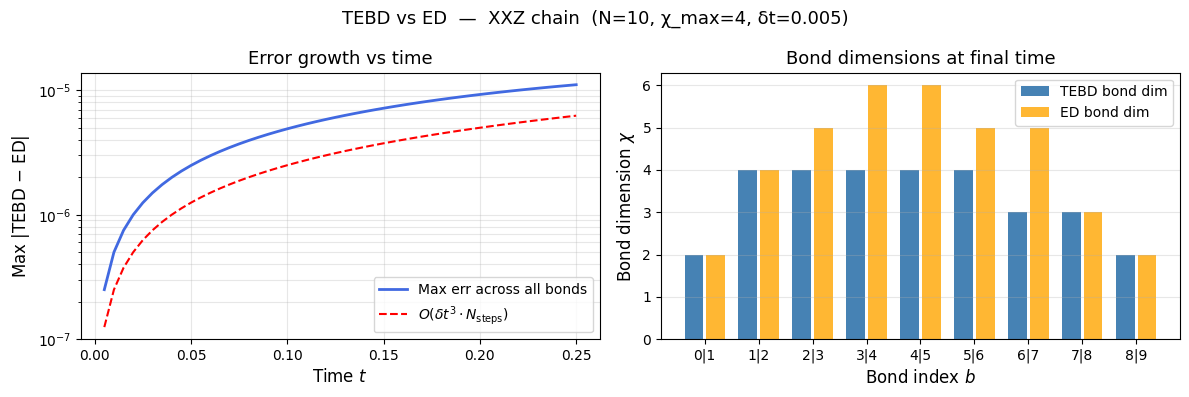

In [31]:
"""
Two-panel figure:
Left  — error growth over time with expected Trotter scaling overlay.
Right — bond dimensions at the final time for TEBD vs ED.
"""
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: error growth vs time ────────────────────────────────────────────
ax = axes[0]
ax.plot(times, max_errors, lw=2, color="royalblue",
        label="Max err across all bonds")
ax.plot(times,
        [dt ** 3 * (s + 1) for s in range(len(times))],
        "r--", lw=1.5, label=r"$O(\delta t^3 \cdot N_\mathrm{steps})$")
ax.set_xlabel(r"Time $t$",          fontsize=12)
ax.set_ylabel(r"Max |TEBD $-$ ED|", fontsize=12)
ax.set_title("Error growth vs time", fontsize=13)
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3, which="both")

# ── Right: bond dimensions at final time ──────────────────────────────────
ax = axes[1]

n_sites_ed = int(np.round(np.log2(len(psi_ed))))   # derived from psi_ed
n_bonds    = n_sites_ed - 1
x          = np.arange(1, n_bonds + 1)

tebd_chi = [len(lam_list[b]) for b in range(1, n_bonds + 1)]
ed_chi   = [len(_ed_schmidt_values(psi_ed, b, n_sites_ed, d))
            for b in range(1, n_bonds + 1)]

ax.bar(x - 0.2, tebd_chi, width=0.35, label="TEBD bond dim",
       color="steelblue")
ax.bar(x + 0.2, ed_chi,   width=0.35, label="ED bond dim",
       color="orange", alpha=0.8)
ax.set_xlabel(r"Bond index $b$",        fontsize=12)
ax.set_ylabel(r"Bond dimension $\chi$", fontsize=12)
ax.set_title("Bond dimensions at final time", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"{b-1}|{b}" for b in range(1, n_bonds + 1)])
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    f"TEBD vs ED  —  XXZ chain  "
    f"(N={n_sites_ed}, χ_max={len(max(lam_list, key=len))}, δt={dt})",
    fontsize=13,
)
fig.tight_layout()
plt.savefig("../figures/ed_comparison.png", dpi=150)
print("  Figure saved → figures/ed_comparison.png")
plt.show()

#### 🍂 **Bond dimension growth**

In [32]:
# --- Physical parameters ---
n_sites = 30  #L
d       = 2
chi_max = 17
dt      = 0.005
n_steps = 2000
Jx, Jy, Jz, hz = -1.0, -1.0, -1.0, 1.0

# --- Initial state |↓↓↑↑↑↑↑↑↑↑⟩ ---
config             = [("down", 2),("up", n_sites-2)]
A_list, lam_list = init_mps(config)

# ── Bond Hamiltonians and Trotter gates ───────────────────────────────────── #
h_left, h_bulk, h_right = build_xxz_two_site(Jx, Jy, Jz, hz)
even_gates, odd_gates     = build_trotter_gates(h_left, h_bulk, h_right, dt)

# gates_L = build_trotter_gates(h_left,  dt)   # left edge bond  (0, 1)
# gates_B = build_trotter_gates(h_bulk,  dt)   # all bulk bonds
# gates_R = build_trotter_gates(h_right, dt)   # right edge bond (L-2, L-1)

print(f"System   : {n_sites} sites, d={d}")
print(f"State    : {config}")
print(f"chi_max  : {chi_max}")
print(f"dt       : {dt},  n_steps : {n_steps}," f"t_final : {n_steps * dt:.3f}")

System   : 30 sites, d=2
State    : [('down', 2), ('up', 28)]
chi_max  : 17
dt       : 0.005,  n_steps : 2000,t_final : 10.000


🌵**Evolution & observable collection**

In [33]:
def run_bond(
    A_list:   list,
    lam_list: list,
    #gates,
    n_sites:  int,
    n_steps:  int,
    dt:       float,
) -> dict:
    """
    Evolve the MPS for *n_steps* Trotter steps and record central-bond
    observables after every step.

    The central bond is defined as bond index ``n_sites // 2``, sitting
    between sites  L/2-1  and  L/2.

    Parameters
    ----------
    A_list   : MPS Gamma tensors (modified in-place by sweep).
    lam_list : MPS singular-value lists (modified in-place by sweep).
    gates    : TrotterGates with .U_half and .U_full  (real-time).
    n_sites  : total number of sites.
    n_steps  : number of Trotter steps to run.
    dt       : time step size.

    Returns
    -------
    dict with keys:
        times       : (n_steps,) array  simulation time after each step.
        bond_dims   : (n_steps,) array  central-bond dimension  χ(t).
        entropies   : (n_steps,) array  central-bond entropy    S(t).
        trunc_errors: (n_steps,) array  total truncation error per step.
    """
    central_bond = (n_sites // 2)

    times        = np.empty(n_steps)
    bond_dims    = np.empty(n_steps, dtype=int)
    entropies    = np.empty(n_steps)
    trunc_errors = np.empty(n_steps)

    print(f"\n{'step':>6}  {'time':>8}  {'χ(L/2)':>8}  "
          f"{'S(L/2)':>12}  {'trunc err':>12}")
    print("-" * 54)
    
    # Perform the 2nd-order step (Even-Odd-Even)
    for step in range(n_steps):
        err  = tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0).total_truncation_error
        err += tebd_sweep(A_list, lam_list, odd_gates,  chi_max, parity=1).total_truncation_error
        err += tebd_sweep(A_list, lam_list, even_gates, chi_max, parity=0).total_truncation_error

        # ── Observables ───────────────────────────────────────────────────────
        t   = (step + 1) * dt
        chi = len(lam_list[central_bond])
        S   = entanglement_entropy_bond(lam=lam_list[central_bond])

        times[step]        = t
        bond_dims[step]    = chi
        entropies[step]    = S
        trunc_errors[step] = err

        if (step + 1) % 50 == 0:
            print(f"{step + 1:>6}  {t:>8.4f}  {chi:>8d}  {S:>12.6f}  {err:>12.2e}")

    return dict(times=times, bond_dims=bond_dims,
                entropies=entropies, trunc_errors=trunc_errors)


In [34]:
results = run_bond(A_list, lam_list, n_sites, n_steps, dt)


  step      time    χ(L/2)        S(L/2)     trunc err
------------------------------------------------------
    50    0.2500         1     -0.000000      3.46e-26
   100    0.5000         1     -0.000000      8.66e-25
   150    0.7500         2     -0.000000      2.21e-25
   200    1.0000         3      0.000000      1.42e-24
   250    1.2500         3      0.000000      3.92e-24
   300    1.5000         4      0.000000      8.89e-25
   350    1.7500         5      0.000001      2.26e-24
   400    2.0000         5      0.000014      4.35e-24
   450    2.2500         6      0.000157      1.50e-24
   500    2.5000         7      0.001155      4.54e-24
   550    2.7500         7      0.005771      2.44e-24
   600    3.0000         8      0.020397      1.63e-24
   650    3.2500         8      0.052701      1.84e-24
   700    3.5000         9      0.102431      1.65e-24
   750    3.7500         9      0.154619      2.65e-24
   800    4.0000         9      0.191073      2.97e-24
   850   

In [35]:
print(f"\n  Final χ(L/2)       : {results['bond_dims'][-1]}")
print(f"  Final S(L/2)       : {results['entropies'][-1]:.6f}")
print(f"  Total trunc. error : {np.sum(results['trunc_errors']):.2e}")


  Final χ(L/2)       : 15
  Final S(L/2)       : 1.092679
  Total trunc. error : 2.87e-21



  Figures → bond_dimension_growth.png


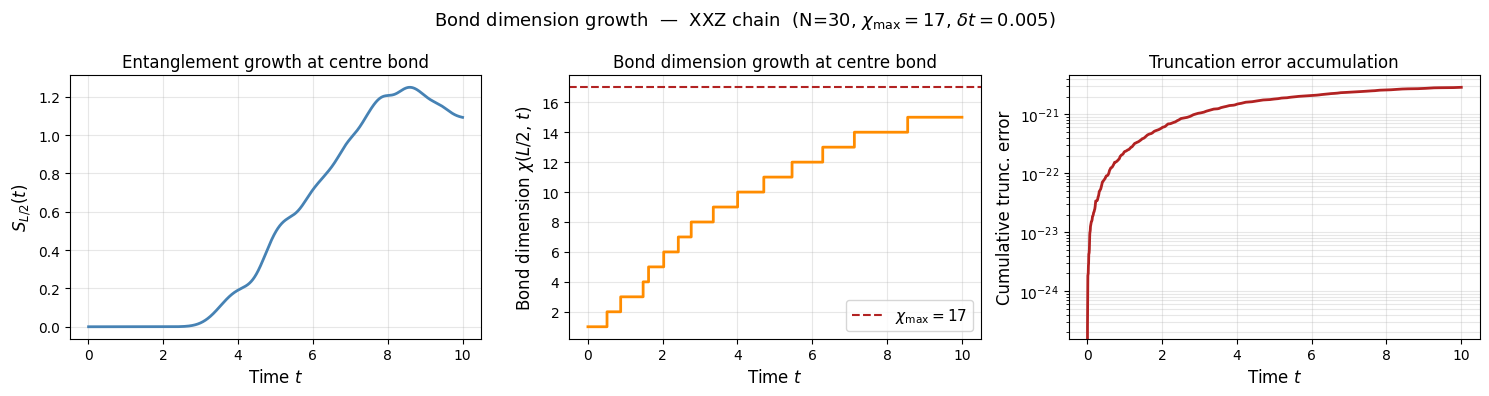

In [36]:
"""
Three-panel figure:
    Left   — entanglement entropy S(L/2, t).
    Centre — bond dimension χ(L/2, t) as a step plot.
    Right  — cumulative truncation error log-scaled.
"""
times        = results["times"]
bond_dims    = results["bond_dims"]
entropies    = results["entropies"]
trunc_errors = results["trunc_errors"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Left: entanglement entropy ────────────────────────────────────────────
ax = axes[0]
ax.plot(times, entropies, lw=2, color="steelblue")
ax.set_xlabel("Time $t$",           fontsize=12)
ax.set_ylabel("$S_{L/2}(t)$",       fontsize=12)
ax.set_title("Entanglement growth at centre bond", fontsize=12)
ax.grid(alpha=0.3)

# ── Centre: bond dimension ────────────────────────────────────────────────
ax = axes[1]
ax.step(times, bond_dims, lw=2, color="darkorange", where="post")
ax.axhline(chi_max, color="firebrick", ls="--", lw=1.5,
            label=f"$\\chi_{{\\max}} = {chi_max}$")
ax.set_xlabel("Time $t$",                          fontsize=12)
ax.set_ylabel(r"Bond dimension $\chi(L/2,\, t)$",  fontsize=12)
ax.set_title("Bond dimension growth at centre bond", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# ── Right: cumulative truncation error ────────────────────────────────────
ax = axes[2]
ax.semilogy(times, np.cumsum(trunc_errors), lw=2, color="firebrick")
ax.set_xlabel("Time $t$",               fontsize=12)
ax.set_ylabel("Cumulative trunc. error", fontsize=12)
ax.set_title("Truncation error accumulation", fontsize=12)
ax.grid(alpha=0.3, which="both")

fig.suptitle(
    f"Bond dimension growth  —  XXZ chain  "
    f"(N={n_sites}, $\\chi_{{\\max}}={chi_max}$, $\\delta t={dt}$)",
    fontsize=13,
)
fig.tight_layout()
plt.savefig("../figures/bond_dimension_growth.png", dpi=150)
print("\n  Figures → bond_dimension_growth.png")
plt.show()